<a href="https://colab.research.google.com/github/hemangrealm/hemangrealm/blob/main/Rainfall.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [9]:
df = pd.read_csv('/content/weatherHistory[1].csv')
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [10]:
df.tail()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.
96452,2016-09-09 23:00:00.000 +0200,Partly Cloudy,rain,20.438889,20.438889,0.61,5.8765,39.0,15.5204,0.0,1016.16,Partly cloudy starting in the morning.


In [11]:
df.shape

(96453, 12)

In [12]:
df.describe()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


In [16]:
df.isnull().sum()

,0
Formatted Date,0
Summary,0
Precip Type,517
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0


In [18]:
correlation = df[[
    'Temperature (C)',
    'Apparent Temperature (C)',
    'Humidity',
    'Wind Speed (km/h)',
    'Wind Bearing (degrees)',
    'Visibility (km)',
    'Loud Cover',
    'Pressure (millibars)'
]].corr()
display(correlation['Temperature (C)'].sort_values(ascending=False))

,Temperature (C)
Temperature (C),1.000000
Apparent Temperature (C),0.992629
Visibility (km),0.392847
Wind Bearing (degrees),0.029988
Wind Speed (km/h),0.008957
Pressure (millibars),-0.005447
Humidity,-0.632255
Loud Cover,NaN


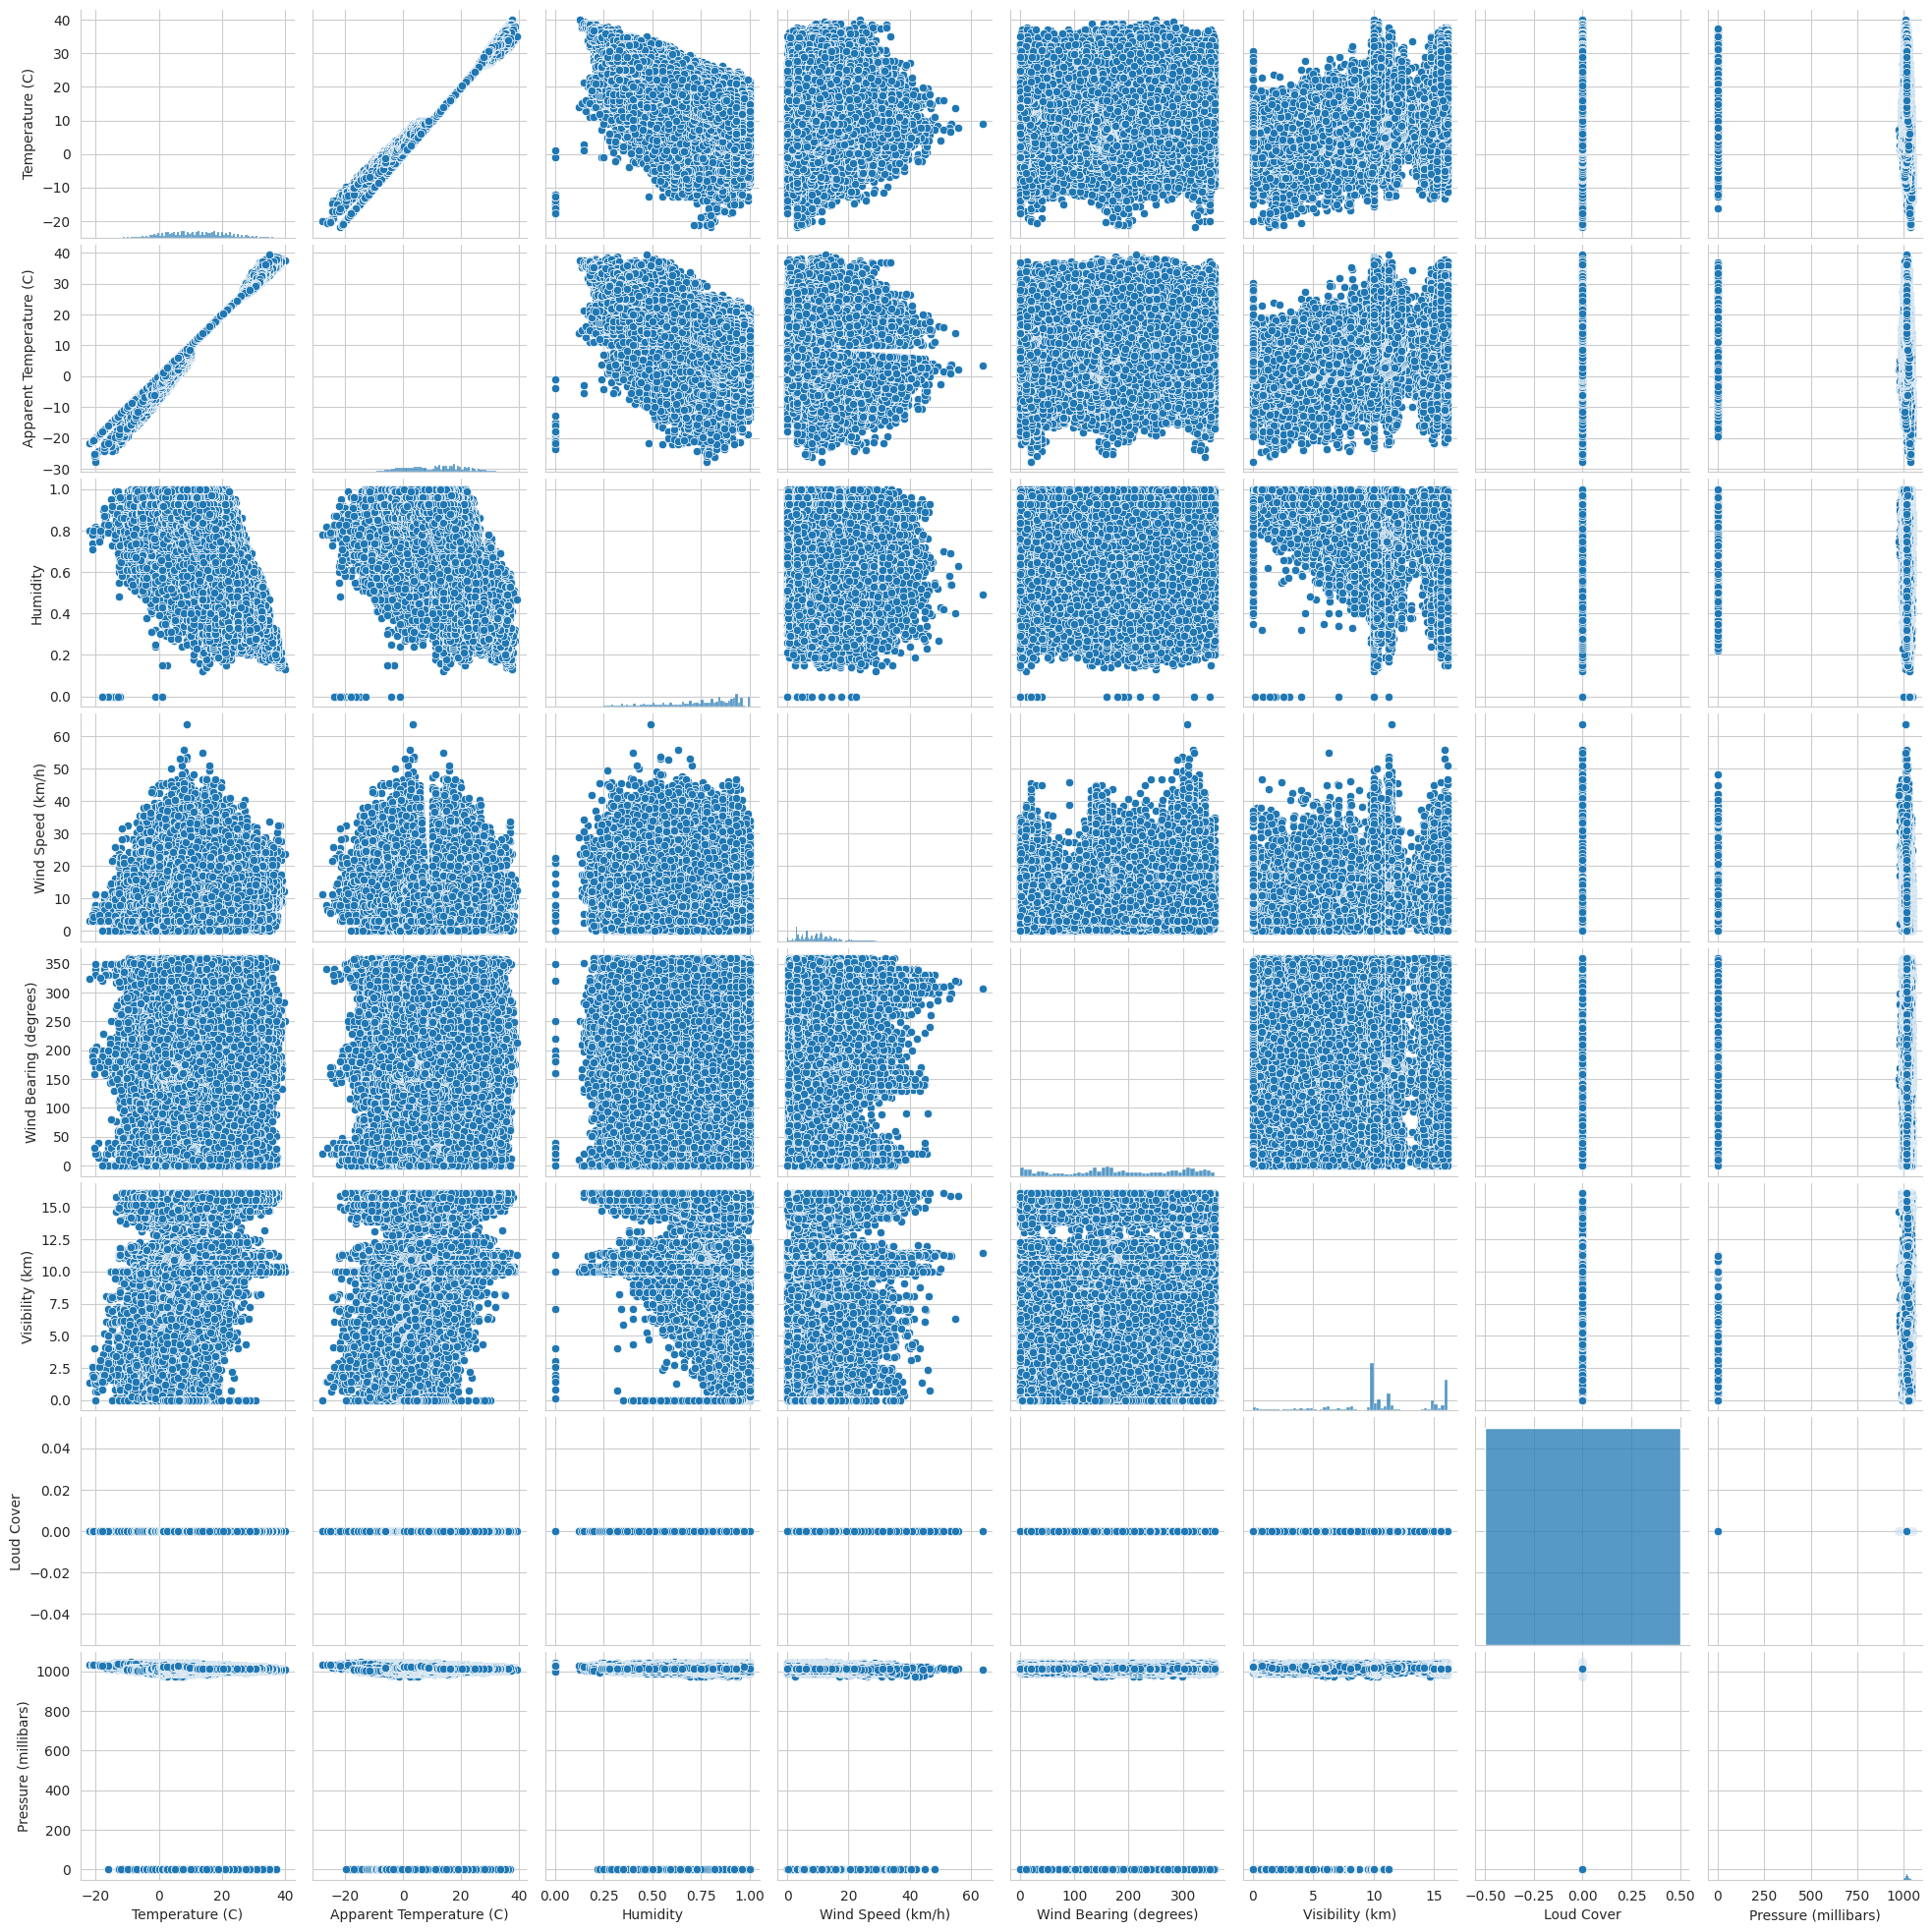

In [19]:
sns.set_style('whitegrid')
sns.pairplot(df)

Text(0.5, 1.0, 'Daily Summary wise Temperature')

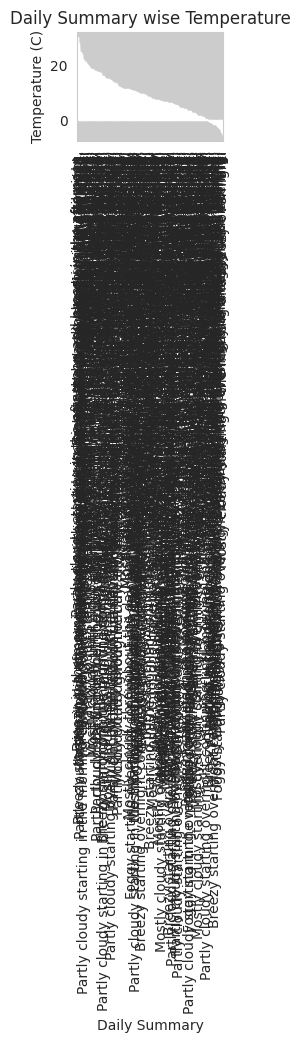

In [20]:
plt.subplot(3, 3, 1)
summary_temp = df.groupby('Daily Summary')['Temperature (C)'].mean().sort_values(ascending=False)
sns.barplot(x = summary_temp.index, y = summary_temp)
summary_temp.plot(kind='bar')
plt.title('Daily Summary wise Temperature')

Text(0.5, 1.0, 'Precip Type wise Temperature')

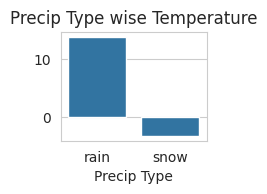

In [22]:
plt.subplot(3, 3, 1)
precip_temp = df.groupby('Precip Type')['Temperature (C)'].mean().sort_values(ascending=False)
sns.barplot(x=precip_temp.index, y=precip_temp.values)
plt.title('Precip Type wise Temperature')

In [23]:
X = df[['Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)']]
y = df['Temperature (C)']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [25]:
print(X_train.shape)
print(X_test.shape)

(67517, 6)
(28936, 6)


In [27]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [28]:
y_pred = model.predict(X_test)

result = pd.DataFrame({
    'Actual_Temperature (C)': y_test.values,
    'Predicted_Temperature (C)': y_pred,
    'Difference (C)': y_test.values - y_pred
})

In [29]:
print(result)

       Actual_Temperature (C)  Predicted_Temperature (C)  Difference (C)
0                   28.122222                  19.986962        8.135260
1                   10.000000                   8.111716        1.888284
2                   14.400000                  13.899014        0.500986
3                    1.016667                   6.719774       -5.703108
4                   -0.122222                   8.603360       -8.725583
...                       ...                        ...             ...
28931               17.150000                  17.937900       -0.787900
28932               -1.144444                   2.626731       -3.771175
28933               19.005556                  16.262218        2.743338
28934               12.777778                   6.959872        5.817906
28935               12.844444                  13.341375       -0.496931

[28936 rows x 3 columns]


In [30]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [35]:
new = pd.DataFrame({
    'Humidity': [0.26,0.42],
    'Wind Speed (km/h)': [10.0,14.7],
    'Wind Bearing (degrees)': [180.0,172.0],
    'Visibility (km)': [10.0, 12.7],
    'Loud Cover': [0.0,13.5],
    'Pressure (millibars)': [1015.0,1017.2]
})
display(new)

,Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
0,0.26,10.0,180.0,10.0,0.0,1015.0
1,0.42,14.7,172.0,12.7,13.5,1017.2


In [36]:
newrecord = model.predict(new)
print(newrecord)

[25.80824406 21.28865849]


In [37]:
print(new)

   Humidity  Wind Speed (km/h)  Wind Bearing (degrees)  Visibility (km)  \
0      0.26               10.0                   180.0             10.0   
1      0.42               14.7                   172.0             12.7   

   Loud Cover  Pressure (millibars)  
0         0.0                1015.0  
1        13.5                1017.2  
